<a href="https://colab.research.google.com/github/lorenja8/heartFailurePrediction/blob/main/heart_failure_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

file_path = '/content/drive/MyDrive/Colab Notebooks/Heart Failure Prediction/heart_failure_clinical_records_dataset.csv'
df = pd.read_csv(file_path)
display(df.head())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


# EDA
Perform an initial exploratory data analysis (EDA) on the DataFrame `df`.

## Display Data Types


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


## Check Missing Values


In [5]:
df.isnull().sum()

,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


## Visualize Data Distributions


Generating Histograms for Numerical Columns:


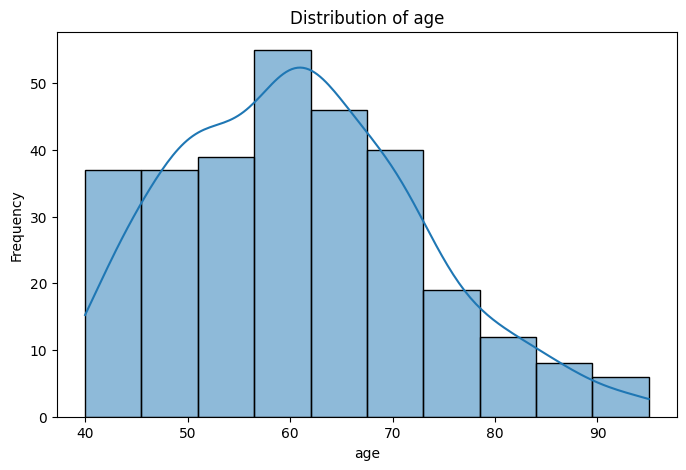

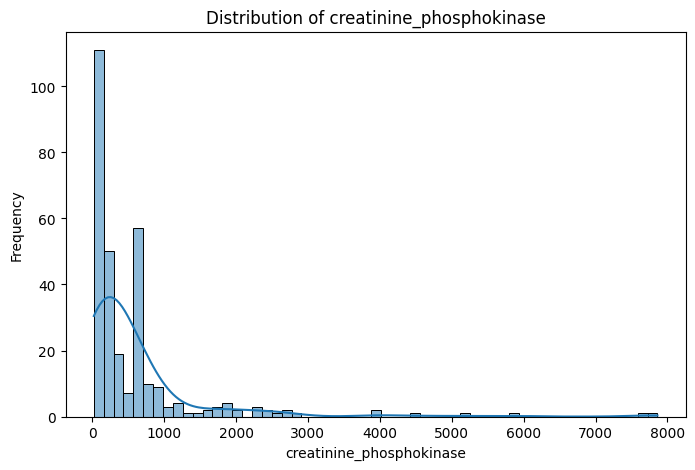

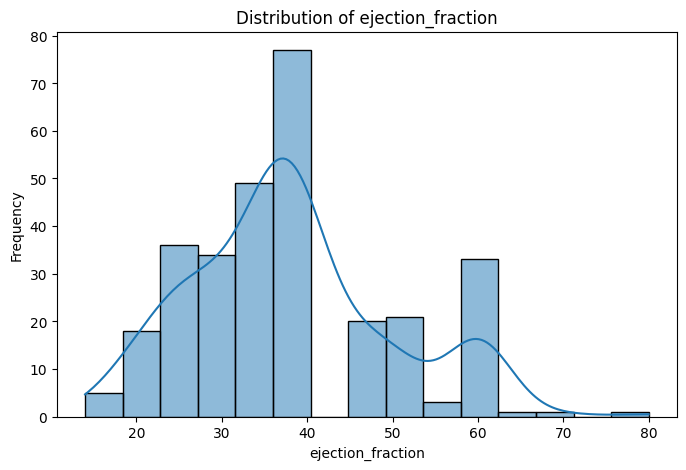

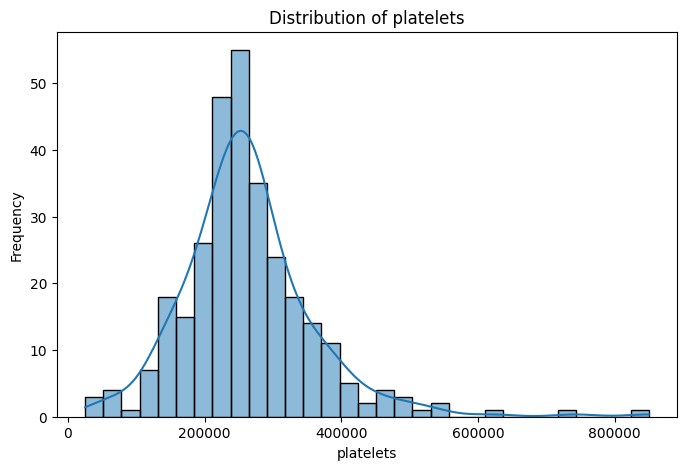

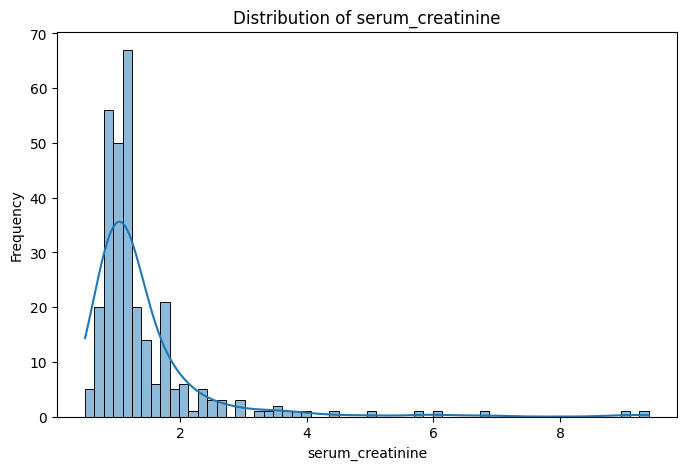

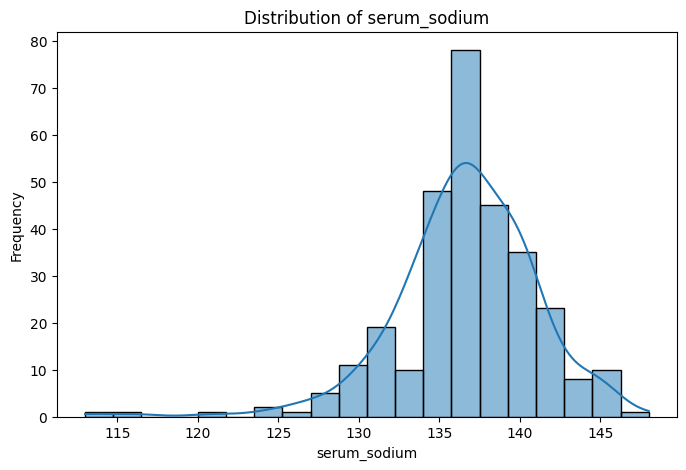

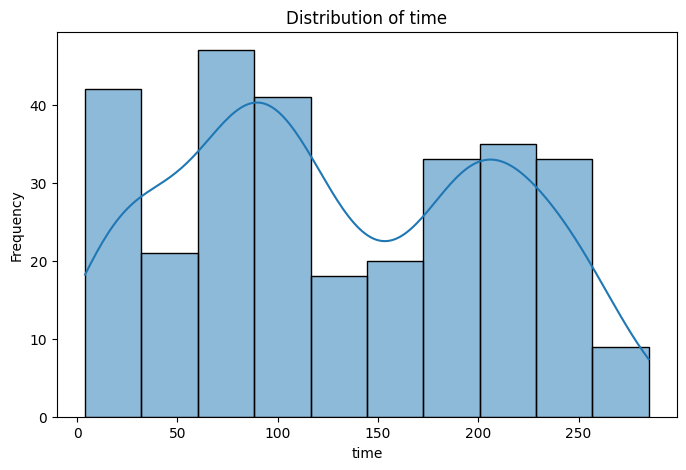


Generating Count Plots for Categorical Columns:


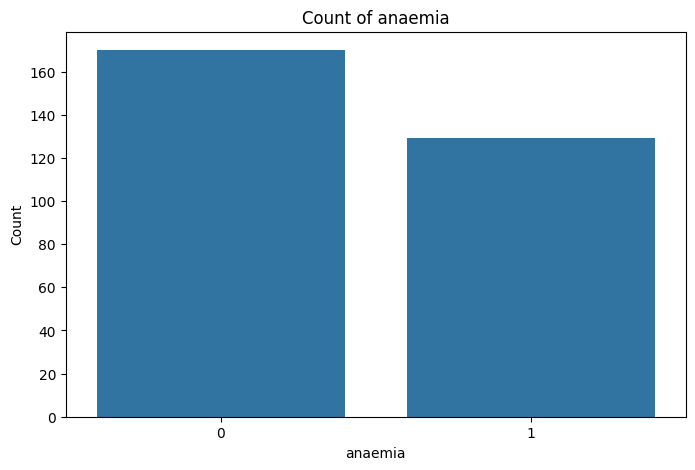

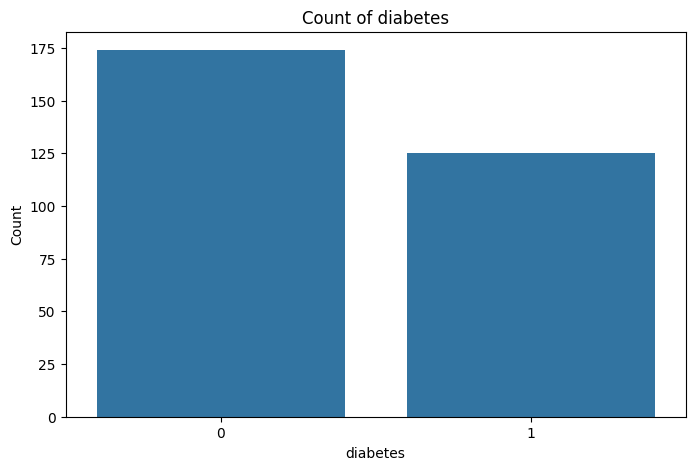

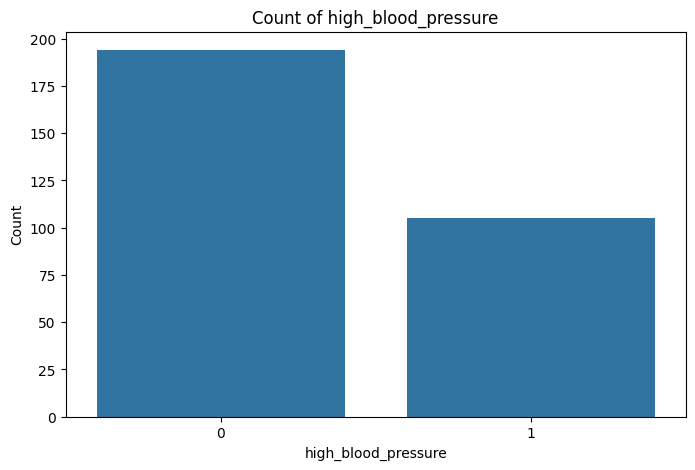

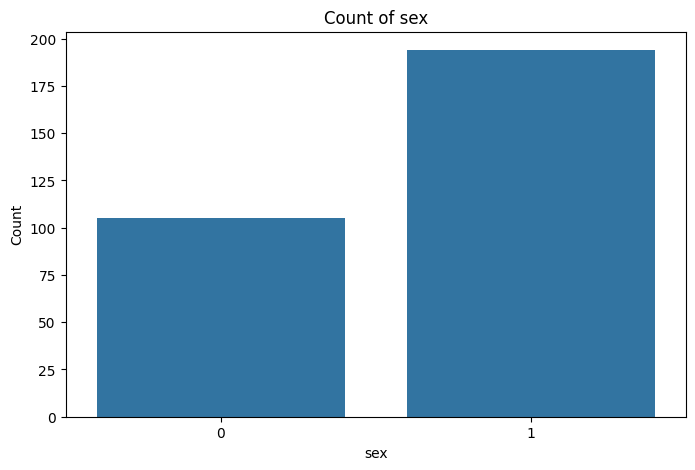

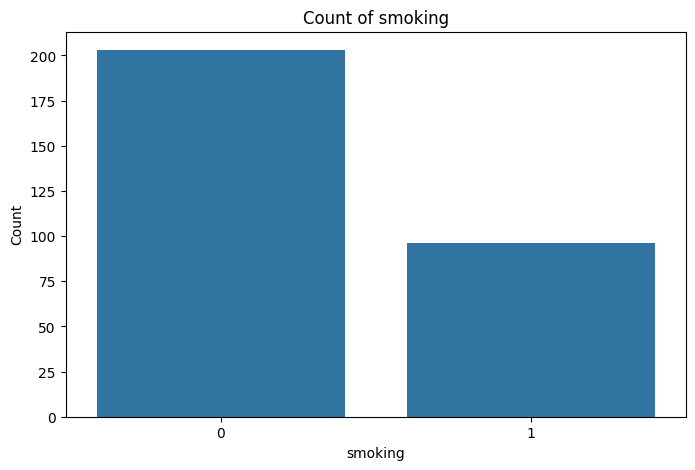

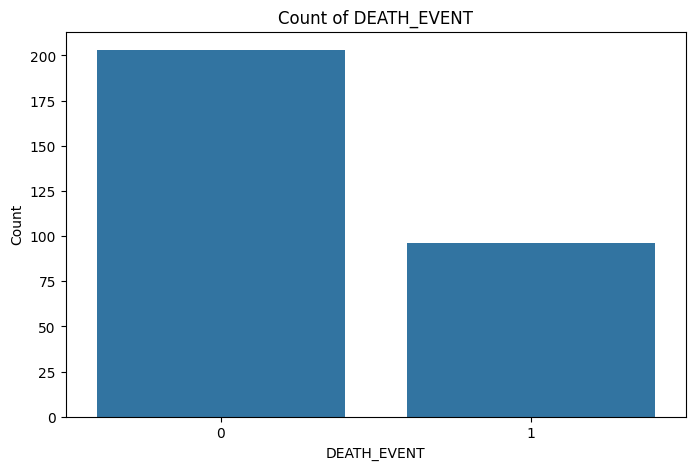

In [6]:
numerical_cols = ['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']
categorical_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']

# Plot histograms for numerical columns
print("Generating Histograms for Numerical Columns:")
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Plot count plots for categorical columns
print("\nGenerating Count Plots for Categorical Columns:")
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df[col])
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## Summary

### Data Analysis Key Findings

*   The DataFrame `df` consists of 299 entries and 13 columns.
*   All 13 columns in the DataFrame have 299 non-null values, indicating that there are no missing values across the entire dataset.
*   The data types are categorized as follows:
    *   `float64`: 3 columns (`age`, `platelets`, `serum_creatinine`).
    *   `int64`: 10 columns (`anaemia`, `creatinine_phosphokinase`, `diabetes`, `ejection_fraction`, `high_blood_pressure`, `serum_sodium`, `sex`, `smoking`, `time`, `DEATH_EVENT`).
*   Data distributions were visualized through 7 histograms for numerical columns and 6 count plots for categorical columns, successfully providing a preliminary look at the variable characteristics.

### Insights or Next Steps

*   The dataset is remarkably clean with no missing values, which simplifies subsequent data preprocessing steps.
*   Review the `int64` columns to identify binary categorical variables (e.g., `anaemia`, `diabetes`, `sex`, `smoking`, `DEATH_EVENT`, `high_blood_pressure`) and consider converting them to a more appropriate categorical data type for clarity and to optimize certain analytical methods.


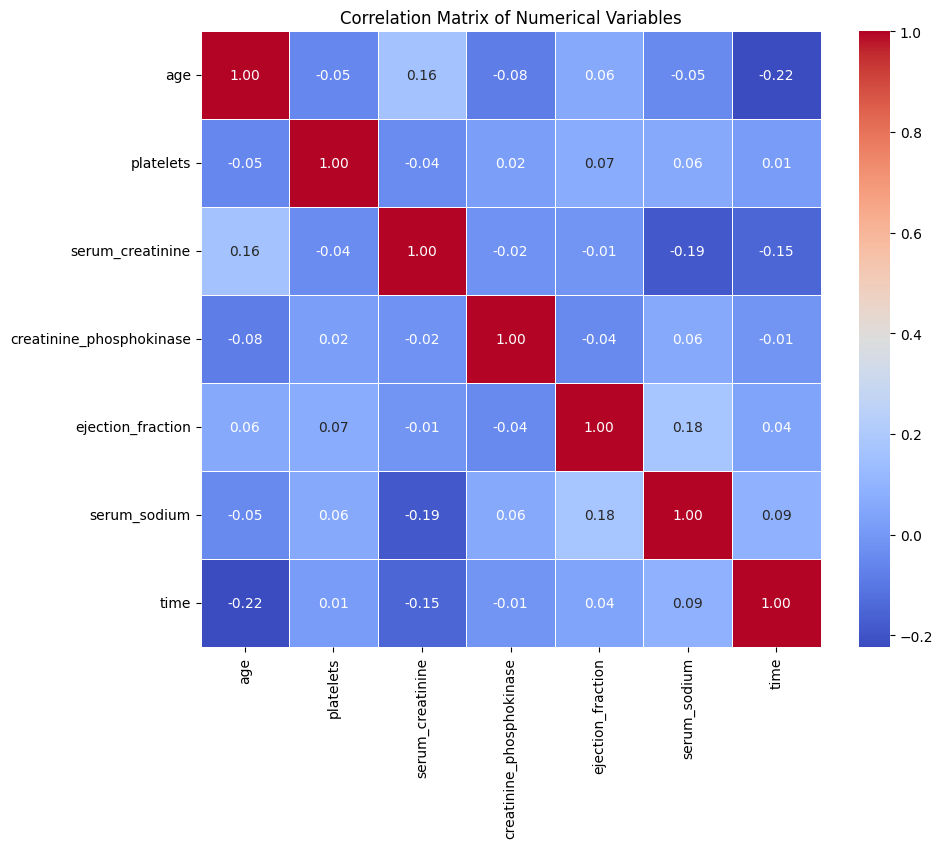

In [7]:
# Define the numerical columns
numerical_cols = ['age', 'platelets', 'serum_creatinine', 'creatinine_phosphokinase', 'ejection_fraction', 'serum_sodium', 'time']

# Calculate the correlation matrix for the numerical columns
correlation_matrix = df[numerical_cols].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

# Data Preprocessing
Scale the 'time' and 'age' columns using `MinMaxScaler`, the 'serum_sodium', 'platelets', and 'ejection_fraction' columns using `StandardScaler`, and the 'serum_creatine' and 'creatinine_phosphokinase' columns using `RobustScaler` within a new DataFrame called `df_scaled`, then display the first few rows of `df_scaled`.

## Initialize Scaling and Scalers

Import necessary libraries (`MinMaxScaler`, `StandardScaler`, `RobustScaler`), define the lists of columns for each scaling method, and create a copy of the original DataFrame `df` named `df_scaled` to hold the transformed data. Initialize the scalers for each method.


In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Define columns for each scaler
min_max_cols = ['time', 'age']
standard_cols = ['serum_sodium', 'platelets', 'ejection_fraction']
robust_cols = ['serum_creatinine', 'creatinine_phosphokinase']

# Create a copy of the DataFrame for scaled data
df_scaled = df.copy()

# Initialize the scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

print("Scalers initialized and column lists defined. A copy of the DataFrame 'df_scaled' has been created.")

Scalers initialized and column lists defined. A copy of the DataFrame 'df_scaled' has been created.


In [9]:
df_scaled[min_max_cols] = min_max_scaler.fit_transform(df_scaled[min_max_cols])
df_scaled[standard_cols] = standard_scaler.fit_transform(df_scaled[standard_cols])
df_scaled[robust_cols] = robust_scaler.fit_transform(df_scaled[robust_cols])

print("Scaled columns have been updated in 'df_scaled'. Displaying the first few rows:")
display(df_scaled.head())

Scaled columns have been updated in 'df_scaled'. Displaying the first few rows:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,0.636364,0,0.713212,0,-1.530560,1,1.681648e-02,1.6,-1.504036,1,0,0.000000,1
1,0.272727,0,16.350161,0,-0.007077,0,7.535660e-09,0.0,-0.141976,1,0,0.007117,1
2,0.454545,0,-0.223416,0,-1.530560,0,-1.038073e+00,0.4,-1.731046,1,1,0.010676,1
3,0.181818,1,-0.298604,0,-1.530560,0,-5.464741e-01,1.6,0.085034,1,0,0.010676,1
4,0.454545,1,-0.193340,1,-1.530560,0,6.517986e-01,3.2,-4.682176,0,0,0.014235,1


## Prepare Data for Machine Learning

### Subtask:
Separate the `df_scaled` DataFrame into input variables (`X`) and the output variable (`y`), where `y` is the `DEATH_EVENT` column and `X` includes all other columns.

In [10]:
# Separate features (X) and target (y)
X = df_scaled.drop('DEATH_EVENT', axis=1)
y = df_scaled['DEATH_EVENT']

print("Shape of X (input variables):", X.shape)
print("Shape of y (output variable):", y.shape)

display(X.head())
display(y.head())

Shape of X (input variables): (299, 12)
Shape of y (output variable): (299,)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
0,0.636364,0,0.713212,0,-1.530560,1,1.681648e-02,1.6,-1.504036,1,0,0.000000
1,0.272727,0,16.350161,0,-0.007077,0,7.535660e-09,0.0,-0.141976,1,0,0.007117
2,0.454545,0,-0.223416,0,-1.530560,0,-1.038073e+00,0.4,-1.731046,1,1,0.010676
3,0.181818,1,-0.298604,0,-1.530560,0,-5.464741e-01,1.6,0.085034,1,0,0.010676
4,0.454545,1,-0.193340,1,-1.530560,0,6.517986e-01,3.2,-4.682176,0,0,0.014235


,DEATH_EVENT
0,1
1,1
2,1
3,1
4,1


## Split Data into Training and Test Sets

### Subtask:
Split the data into training and test sets using a 70:30 ratio, ensuring that the distribution of the target variable (`DEATH_EVENT`) is maintained in both sets (stratified split).

In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (70:30 ratio) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of DEATH_EVENT in original data:")
print(y.value_counts(normalize=True))
print("\nDistribution of DEATH_EVENT in training set:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of DEATH_EVENT in test set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (209, 12)
Shape of X_test: (90, 12)
Shape of y_train: (209,)
Shape of y_test: (90,)

Distribution of DEATH_EVENT in original data:
DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

Distribution of DEATH_EVENT in training set:
DEATH_EVENT
0    0.679426
1    0.320574
Name: proportion, dtype: float64

Distribution of DEATH_EVENT in test set:
DEATH_EVENT
0    0.677778
1    0.322222
Name: proportion, dtype: float64


# Logistic Regression

## Hyperparameter Tuning for Logistic Regression

Perform hyperparameter tuning on the Logistic Regression model using `RandomizedSearchCV`. Define a parameter distribution for `penalty` (l1, l2), `C` (inverse of regularization strength), `solver` (liblinear, saga), and `max_iter`. Fit `RandomizedSearchCV` on `X_train` and `y_train` to find the best parameters and the best score. Display the best parameters and best score.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV

# 1. Define a parameter distribution dictionary
param_dist = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-3, 2, 6).tolist(),  # Inverse of regularization strength
    'solver': ['liblinear', 'saga'],
    'max_iter': list(range(100, 501, 50))
}

# 2. Instantiate a LogisticRegression model
log_reg = LogisticRegression(random_state=42)

# 3. Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=5,       # 5-fold cross-validation
    scoring='roc_auc', # Metric to optimize
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# 4. Fit RandomizedSearchCV to your training data
random_search.fit(X_train, y_train)

# 5. Print the best parameters found
print("Best parameters found by RandomizedSearchCV:")
print(random_search.best_params_)

# 6. Print the best score (ROC AUC) found
print("Best ROC AUC score:", random_search.best_score_)


Best parameters found by RandomizedSearchCV:
{'solver': 'liblinear', 'penalty': 'l1', 'max_iter': 500, 'C': 0.1}
Best ROC AUC score: 0.8811725220592216


## Evaluate Tuned Model Performance

After finding the best hyperparameters, retrain the Logistic Regression model with these optimal settings. Then, evaluate its performance on `X_test` using accuracy, precision, recall, and ROC AUC, displaying the tabular metrics and the ROC curve plot as previously established.



Evaluation Metrics for Tuned Logistic Regression Model:


,Metric,Score
0,Accuracy,0.744444
1,Precision (Class 0),0.756757
2,Recall (Class 0),0.918033
3,Precision (Class 1),0.687500
4,Recall (Class 1),0.379310



ROC AUC score for Tuned Logistic Regression model: 0.8445


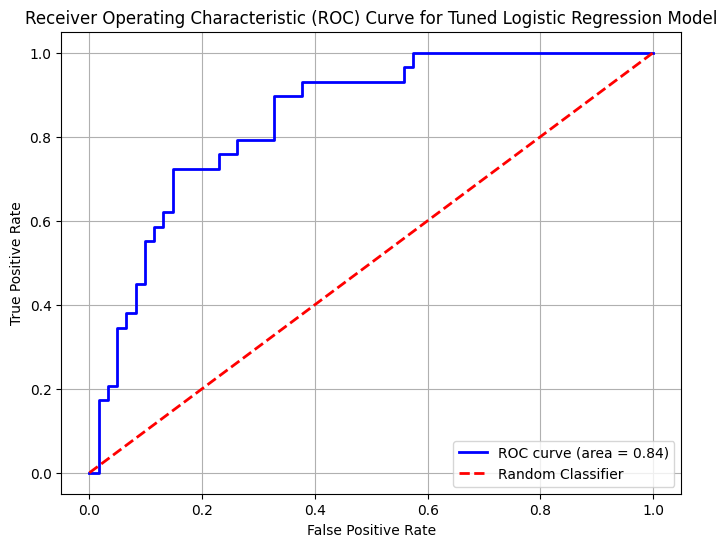

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, roc_curve

# 1. Retrieve the best estimator
best_log_reg_model = random_search.best_estimator_

# 2. Use this tuned model to make predictions on the X_test dataset
y_pred_tuned = best_log_reg_model.predict(X_test)

# 3. Get the predicted probabilities for the positive class (class 1)
y_pred_proba_tuned = best_log_reg_model.predict_proba(X_test)[:, 1]

# 4. Calculate accuracy, precision, and recall scores
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

# Generate a classification report for detailed precision and recall
report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True, zero_division=0)

# 5. Calculate the ROC AUC score
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

# 6. Display tabular metrics
metrics_data_tuned = {
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'Precision (Class 1)', 'Recall (Class 1)'],
    'Score': [
        accuracy_tuned,
        report_tuned['0']['precision'],
        report_tuned['0']['recall'],
        report_tuned['1']['precision'],
        report_tuned['1']['recall']
    ]
}

metrics_df_tuned = pd.DataFrame(metrics_data_tuned)

print("\nEvaluation Metrics for Tuned Logistic Regression Model:")
display(metrics_df_tuned)

# 7. Print the ROC AUC score
print(f"\nROC AUC score for Tuned Logistic Regression model: {roc_auc_tuned:.4f}")

# 8. Calculate FPR, TPR, and thresholds for the ROC curve
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, y_pred_proba_tuned)

# 9. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned, tpr_tuned, color='blue', lw=2, label=f'ROC curve (area = {roc_auc_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned Logistic Regression Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Random Forest Classifier

## Hyperparameter Tuning for Random Forest Classifier

Perform hyperparameter tuning on the Random Forest Classifier using `RandomizedSearchCV`. Define a parameter distribution for key hyperparameters like `n_estimators`, `max_depth`, `min_samples_split`, and `min_samples_leaf`. Fit `RandomizedSearchCV` on `X_train` and `y_train` to find the best parameters and the best score. Display the best parameters and best score.


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for RandomForestClassifier
param_dist_rf = {
    'n_estimators': list(range(100, 501, 50)),  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30, 40, 50], # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4] # Minimum number of samples required to be at a leaf node
}

# Instantiate a RandomForestClassifier model
rf_model_tuned = RandomForestClassifier(random_state=42)

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_model_tuned,
    param_distributions=param_dist_rf,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=5,       # 5-fold cross-validation
    scoring='roc_auc', # Metric to optimize
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# Fit RandomizedSearchCV to your training data
random_search_rf.fit(X_train, y_train)

# Print the best parameters found
print("Best parameters found by RandomizedSearchCV for Random Forest:")
print(random_search_rf.best_params_)

# Print the best score (ROC AUC) found
print("Best ROC AUC score for Random Forest:", random_search_rf.best_score_)


Best parameters found by RandomizedSearchCV for Random Forest:
{'n_estimators': 350, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': None}
Best ROC AUC score for Random Forest: 0.9252814919071077


## Evaluate Tuned Random Forest Performance

### Subtask:
After finding the best hyperparameters for the Random Forest model, retrain it with these optimal settings. Then, evaluate its performance on `X_test` using accuracy, precision, recall, and ROC AUC, displaying the tabular metrics and the ROC curve plot.


**Reasoning**:
To evaluate the tuned Random Forest model, I will retrieve the best estimator from `random_search_rf`, make predictions and calculate probabilities on the test set, then compute and display accuracy, precision, recall, and ROC AUC scores. Finally, I will present the tabular metrics and visualize the ROC curve.




Evaluation Metrics for Tuned Random Forest Model:


,Metric,Score
0,Accuracy,0.833333
1,Precision (Class 0),0.828571
2,Recall (Class 0),0.950820
3,Precision (Class 1),0.850000
4,Recall (Class 1),0.586207



ROC AUC score for Tuned Random Forest model: 0.8949


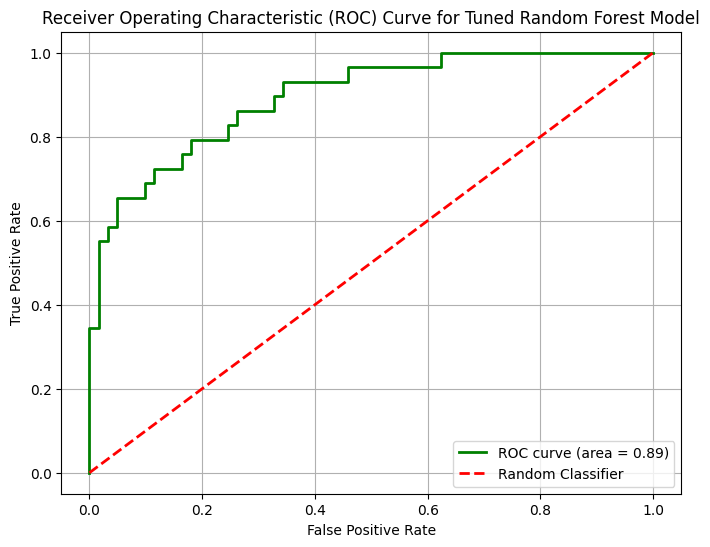

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, roc_curve

# 1. Retrieve the best estimator
best_rf_model = random_search_rf.best_estimator_

# 2. Use this tuned model to make predictions on the X_test dataset
y_pred_tuned_rf = best_rf_model.predict(X_test)

# 3. Get the predicted probabilities for the positive class (class 1)
y_pred_proba_tuned_rf = best_rf_model.predict_proba(X_test)[:, 1]

# 4. Calculate accuracy score
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)

# 5. Generate a classification report for detailed precision and recall
report_tuned_rf = classification_report(y_test, y_pred_tuned_rf, output_dict=True, zero_division=0)

# 6. Create a Pandas DataFrame to display the metrics
metrics_data_tuned_rf = {
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'Precision (Class 1)', 'Recall (Class 1)'],
    'Score': [
        accuracy_tuned_rf,
        report_tuned_rf['0']['precision'],
        report_tuned_rf['0']['recall'],
        report_tuned_rf['1']['precision'],
        report_tuned_rf['1']['recall']
    ]
}

metrics_df_tuned_rf = pd.DataFrame(metrics_data_tuned_rf)

print("\nEvaluation Metrics for Tuned Random Forest Model:")
display(metrics_df_tuned_rf)

# 7. Calculate the ROC AUC score
roc_auc_tuned_rf = roc_auc_score(y_test, y_pred_proba_tuned_rf)

# 8. Print the ROC AUC score
print(f"\nROC AUC score for Tuned Random Forest model: {roc_auc_tuned_rf:.4f}")

# 9. Calculate FPR, TPR, and thresholds for the ROC curve
fpr_tuned_rf, tpr_tuned_rf, thresholds_tuned_rf = roc_curve(y_test, y_pred_proba_tuned_rf)

# 10. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned_rf, tpr_tuned_rf, color='green', lw=2, label=f'ROC curve (area = {roc_auc_tuned_rf:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# XGBoost Classifier

## Hyperparameter Tuning for XGBoost Classifier

Perform hyperparameter tuning on the XGBoost Classifier using `RandomizedSearchCV`. Define a parameter distribution for key hyperparameters such as `n_estimators`, `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`. Fit `RandomizedSearchCV` on `X_train` and `y_train` to find the best parameters and the best score. Display the best parameters and best score.


In [16]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for XGBoost Classifier
param_dist_xgb = {
    'n_estimators': list(range(100, 501, 50)),
    'learning_rate': np.logspace(-3, 0, 4).tolist(), # e.g., 0.001, 0.01, 0.1, 1.0
    'max_depth': [3, 5, 7, 9, None],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Instantiate an XGBoost Classifier model
xgb_tuned_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tuned_model,
    param_distributions=param_dist_xgb,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=5,       # 5-fold cross-validation
    scoring='roc_auc', # Metric to optimize
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# Fit RandomizedSearchCV to your training data
random_search_xgb.fit(X_train, y_train)

# Print the best parameters found
print("Best parameters found by RandomizedSearchCV for XGBoost:")
print(random_search_xgb.best_params_)

# Print the best score (ROC AUC) found
print("Best ROC AUC score for XGBoost:", random_search_xgb.best_score_)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:27:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found by RandomizedSearchCV for XGBoost:
{'subsample': 0.6, 'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best ROC AUC score for XGBoost: 0.9213500784929357


**Reasoning**:
The previous code generated a UserWarning about the `use_label_encoder` parameter being unused. To address this warning and provide a cleaner execution, I will remove the `use_label_encoder=False` parameter from the `XGBClassifier` initialization, as it is no longer necessary and causes the warning.



In [17]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for XGBoost Classifier
param_dist_xgb = {
    'n_estimators': list(range(100, 501, 50)),
    'learning_rate': np.logspace(-3, 0, 4).tolist(), # e.g., 0.001, 0.01, 0.1, 1.0
    'max_depth': [3, 5, 7, 9, None],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

# Instantiate an XGBoost Classifier model
xgb_tuned_model = XGBClassifier(random_state=42, eval_metric='logloss')

# Initialize RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_tuned_model,
    param_distributions=param_dist_xgb,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=5,       # 5-fold cross-validation
    scoring='roc_auc', # Metric to optimize
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# Fit RandomizedSearchCV to your training data
random_search_xgb.fit(X_train, y_train)

# Print the best parameters found
print("Best parameters found by RandomizedSearchCV for XGBoost:")
print(random_search_xgb.best_params_)

# Print the best score (ROC AUC) found
print("Best ROC AUC score for XGBoost:", random_search_xgb.best_score_)

Best parameters found by RandomizedSearchCV for XGBoost:
{'subsample': 0.6, 'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best ROC AUC score for XGBoost: 0.9213500784929357


## Evaluate Tuned XGBoost Performance

After finding the best hyperparameters for the XGBoost model, retrain it with these optimal settings. Then, evaluate its performance on `X_test` using accuracy, precision, recall, and ROC AUC, displaying the tabular metrics and the ROC curve plot.

**Reasoning**:
To evaluate the tuned XGBoost model, I will retrieve the best estimator from `random_search_xgb`, make predictions and calculate probabilities on the test set, then compute and display accuracy, precision, recall, and ROC AUC scores. Finally, I will present the tabular metrics and visualize the ROC curve.

**Reasoning**:
Now that the reasoning is provided, I will implement the code to retrieve the best estimator, make predictions, calculate and display performance metrics in a tabular format, print the ROC AUC score, and plot the ROC curve for the tuned XGBoost model.




Evaluation Metrics for Tuned XGBoost Model:


,Metric,Score
0,Accuracy,0.844444
1,Precision (Class 0),0.840580
2,Recall (Class 0),0.950820
3,Precision (Class 1),0.857143
4,Recall (Class 1),0.620690



ROC AUC score for Tuned XGBoost model: 0.8705


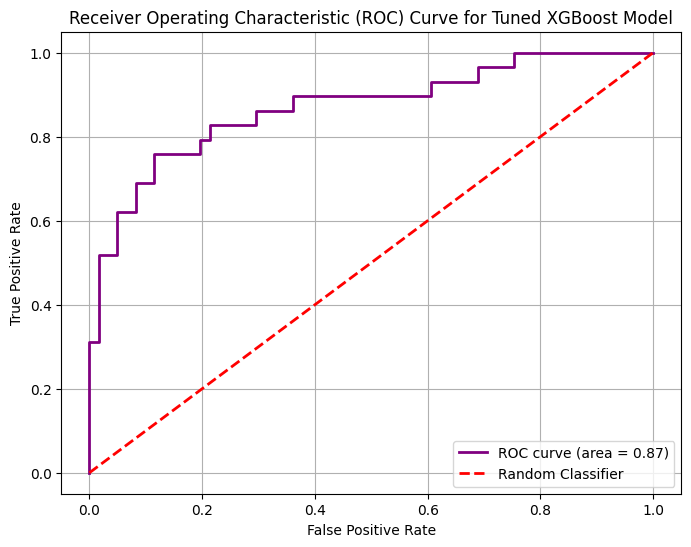

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, roc_curve

# 1. Retrieve the best estimator
best_xgb_model = random_search_xgb.best_estimator_

# 2. Use this tuned model to make predictions on the X_test dataset
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# 3. Get the predicted probabilities for the positive class (class 1)
y_pred_proba_tuned_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# 4. Calculate accuracy score
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)

# 5. Generate a classification report for detailed precision and recall
report_tuned_xgb = classification_report(y_test, y_pred_tuned_xgb, output_dict=True, zero_division=0)

# 6. Create a Pandas DataFrame to display the metrics
metrics_data_tuned_xgb = {
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'Precision (Class 1)', 'Recall (Class 1)'],
    'Score': [
        accuracy_tuned_xgb,
        report_tuned_xgb['0']['precision'],
        report_tuned_xgb['0']['recall'],
        report_tuned_xgb['1']['precision'],
        report_tuned_xgb['1']['recall']
    ]
}

metrics_df_tuned_xgb = pd.DataFrame(metrics_data_tuned_xgb)

print("\nEvaluation Metrics for Tuned XGBoost Model:")
display(metrics_df_tuned_xgb)

# 7. Calculate the ROC AUC score
roc_auc_tuned_xgb = roc_auc_score(y_test, y_pred_proba_tuned_xgb)

# 8. Print the ROC AUC score
print(f"\nROC AUC score for Tuned XGBoost model: {roc_auc_tuned_xgb:.4f}")

# 9. Calculate FPR, TPR, and thresholds for the ROC curve
fpr_tuned_xgb, tpr_tuned_xgb, thresholds_tuned_xgb = roc_curve(y_test, y_pred_proba_tuned_xgb)

# 10. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned_xgb, tpr_tuned_xgb, color='purple', lw=2, label=f'ROC curve (area = {roc_auc_tuned_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned XGBoost Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# kNN Classifier

## Hyperparameter Tuning for kNN Classifier

Perform hyperparameter tuning on the kNN Classifier using `RandomizedSearchCV`. Define a parameter distribution for key hyperparameters like `n_neighbors`, `weights`, and `metric`. Fit `RandomizedSearchCV` on `X_train` and `y_train` to find the best parameters and the best score. Display the best parameters and best score.


In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define a parameter distribution for kNN Classifier
param_dist_knn = {
    'n_neighbors': list(range(1, 31)),  # Number of neighbors
    'weights': ['uniform', 'distance'],  # Weight function used in prediction
    'metric': ['euclidean', 'manhattan'] # Distance metric
}

# Instantiate a KNeighborsClassifier model
knn_tuned_model = KNeighborsClassifier()

# Initialize RandomizedSearchCV
random_search_knn = RandomizedSearchCV(
    estimator=knn_tuned_model,
    param_distributions=param_dist_knn,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=5,       # 5-fold cross-validation
    scoring='roc_auc', # Metric to optimize
    random_state=42,
    n_jobs=-1   # Use all available CPU cores
)

# Fit RandomizedSearchCV to your training data
random_search_knn.fit(X_train, y_train)

# Print the best parameters found
print("Best parameters found by RandomizedSearchCV for kNN:")
print(random_search_knn.best_params_)

# Print the best score (ROC AUC) found
print("Best ROC AUC score for kNN:", random_search_knn.best_score_)

Best parameters found by RandomizedSearchCV for kNN:
{'weights': 'uniform', 'n_neighbors': 30, 'metric': 'manhattan'}
Best ROC AUC score for kNN: 0.8402080062794347


## Evaluate Tuned kNN Performance

After finding the best hyperparameters for the kNN model, retrain it with these optimal settings. Then, evaluate its performance on `X_test` using accuracy, precision, recall, and ROC AUC, displaying the tabular metrics and the ROC curve plot.



Evaluation Metrics for Tuned kNN Model:


,Metric,Score
0,Accuracy,0.722222
1,Precision (Class 0),0.714286
2,Recall (Class 0),0.983607
3,Precision (Class 1),0.833333
4,Recall (Class 1),0.172414



ROC AUC score for Tuned kNN model: 0.7541


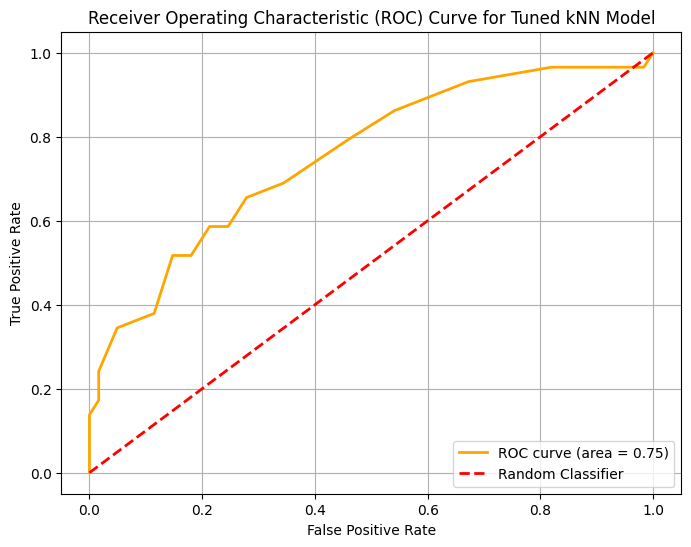

In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, roc_curve

# 1. Retrieve the best estimator
best_knn_model = random_search_knn.best_estimator_

# 2. Use this tuned model to make predictions on the X_test dataset
y_pred_tuned_knn = best_knn_model.predict(X_test)

# 3. Get the predicted probabilities for the positive class (class 1)
y_pred_proba_tuned_knn = best_knn_model.predict_proba(X_test)[:, 1]

# 4. Calculate accuracy score
accuracy_tuned_knn = accuracy_score(y_test, y_pred_tuned_knn)

# 5. Generate a classification report for detailed precision and recall
report_tuned_knn = classification_report(y_test, y_pred_tuned_knn, output_dict=True, zero_division=0)

# 6. Create a Pandas DataFrame to display the metrics
metrics_data_tuned_knn = {
    'Metric': ['Accuracy', 'Precision (Class 0)', 'Recall (Class 0)', 'Precision (Class 1)', 'Recall (Class 1)'],
    'Score': [
        accuracy_tuned_knn,
        report_tuned_knn['0']['precision'],
        report_tuned_knn['0']['recall'],
        report_tuned_knn['1']['precision'],
        report_tuned_knn['1']['recall']
    ]
}

metrics_df_tuned_knn = pd.DataFrame(metrics_data_tuned_knn)

print("\nEvaluation Metrics for Tuned kNN Model:")
display(metrics_df_tuned_knn)

# 7. Calculate the ROC AUC score
roc_auc_tuned_knn = roc_auc_score(y_test, y_pred_proba_tuned_knn)

# 8. Print the ROC AUC score
print(f"\nROC AUC score for Tuned kNN model: {roc_auc_tuned_knn:.4f}")

# 9. Calculate FPR, TPR, and thresholds for the ROC curve
fpr_tuned_knn, tpr_tuned_knn, thresholds_tuned_knn = roc_curve(y_test, y_pred_proba_tuned_knn)

# 10. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_tuned_knn, tpr_tuned_knn, color='orange', lw=2, label=f'ROC curve (area = {roc_auc_tuned_knn:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned kNN Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Model Comparison
Collect the accuracy, precision (Class 0 & 1), recall (Class 0 & 1), and ROC AUC scores for the tuned Logistic Regression, Random Forest, XGBoost, and kNN models. Then, create and display a well-formatted table that presents these key performance metrics for all tuned models, enabling easy side-by-side comparison.

## Collect and Consolidate Metrics

Gather the accuracy, precision (Class 0 & 1), recall (Class 0 & 1), and ROC AUC scores for each of the tuned Logistic Regression, Random Forest, XGBoost, and kNN models.


In [21]:
model_metrics = []

# Metrics for Tuned Logistic Regression
model_metrics.append({
    'Model': 'Tuned Logistic Regression',
    'Accuracy': accuracy_tuned,
    'Precision (Class 0)': report_tuned['0']['precision'],
    'Recall (Class 0)': report_tuned['0']['recall'],
    'Precision (Class 1)': report_tuned['1']['precision'],
    'Recall (Class 1)': report_tuned['1']['recall'],
    'ROC AUC Score': roc_auc_tuned
})

# Metrics for Tuned Random Forest
model_metrics.append({
    'Model': 'Tuned Random Forest',
    'Accuracy': accuracy_tuned_rf,
    'Precision (Class 0)': report_tuned_rf['0']['precision'],
    'Recall (Class 0)': report_tuned_rf['0']['recall'],
    'Precision (Class 1)': report_tuned_rf['1']['precision'],
    'Recall (Class 1)': report_tuned_rf['1']['recall'],
    'ROC AUC Score': roc_auc_tuned_rf
})

# Metrics for Tuned XGBoost
model_metrics.append({
    'Model': 'Tuned XGBoost',
    'Accuracy': accuracy_tuned_xgb,
    'Precision (Class 0)': report_tuned_xgb['0']['precision'],
    'Recall (Class 0)': report_tuned_xgb['0']['recall'],
    'Precision (Class 1)': report_tuned_xgb['1']['precision'],
    'Recall (Class 1)': report_tuned_xgb['1']['recall'],
    'ROC AUC Score': roc_auc_tuned_xgb
})

# Metrics for Tuned kNN
model_metrics.append({
    'Model': 'Tuned kNN',
    'Accuracy': accuracy_tuned_knn,
    'Precision (Class 0)': report_tuned_knn['0']['precision'],
    'Recall (Class 0)': report_tuned_knn['0']['recall'],
    'Precision (Class 1)': report_tuned_knn['1']['precision'],
    'Recall (Class 1)': report_tuned_knn['1']['recall'],
    'ROC AUC Score': roc_auc_tuned_knn
})

print("Consolidated metrics for all tuned models:")
print(model_metrics)

Consolidated metrics for all tuned models:
[{'Model': 'Tuned Logistic Regression', 'Accuracy': 0.7444444444444445, 'Precision (Class 0)': 0.7567567567567568, 'Recall (Class 0)': 0.9180327868852459, 'Precision (Class 1)': 0.6875, 'Recall (Class 1)': 0.3793103448275862, 'ROC AUC Score': np.float64(0.844544940644432)}, {'Model': 'Tuned Random Forest', 'Accuracy': 0.8333333333333334, 'Precision (Class 0)': 0.8285714285714286, 'Recall (Class 0)': 0.9508196721311475, 'Precision (Class 1)': 0.85, 'Recall (Class 1)': 0.5862068965517241, 'ROC AUC Score': np.float64(0.894855850763143)}, {'Model': 'Tuned XGBoost', 'Accuracy': 0.8444444444444444, 'Precision (Class 0)': 0.8405797101449275, 'Recall (Class 0)': 0.9508196721311475, 'Precision (Class 1)': 0.8571428571428571, 'Recall (Class 1)': 0.6206896551724138, 'ROC AUC Score': np.float64(0.8705483323911815)}, {'Model': 'Tuned kNN', 'Accuracy': 0.7222222222222222, 'Precision (Class 0)': 0.7142857142857143, 'Recall (Class 0)': 0.9836065573770492, 'Pr

In [22]:
# Create a DataFrame from the collected metrics
comparison_df = pd.DataFrame(model_metrics)

# Set 'Model' as the index for better readability
comparison_df = comparison_df.set_index('Model')

print("\nComparative Analysis of Tuned Models:")
display(comparison_df)



Comparative Analysis of Tuned Models:


,Accuracy,Precision (Class 0),Recall (Class 0),Precision (Class 1),Recall (Class 1),ROC AUC Score
Model,,,,,,
Tuned Logistic Regression,0.744444,0.756757,0.918033,0.687500,0.379310,0.844545
Tuned Random Forest,0.833333,0.828571,0.950820,0.850000,0.586207,0.894856
Tuned XGBoost,0.844444,0.840580,0.950820,0.857143,0.620690,0.870548
Tuned kNN,0.722222,0.714286,0.983607,0.833333,0.172414,0.754098


## Visualize Model Performance

Generate a comparative plot, such as a bar chart, to visualize and compare the ROC AUC scores or accuracy of all tuned models. Ensure the plot has a clear title, labels, and legend.


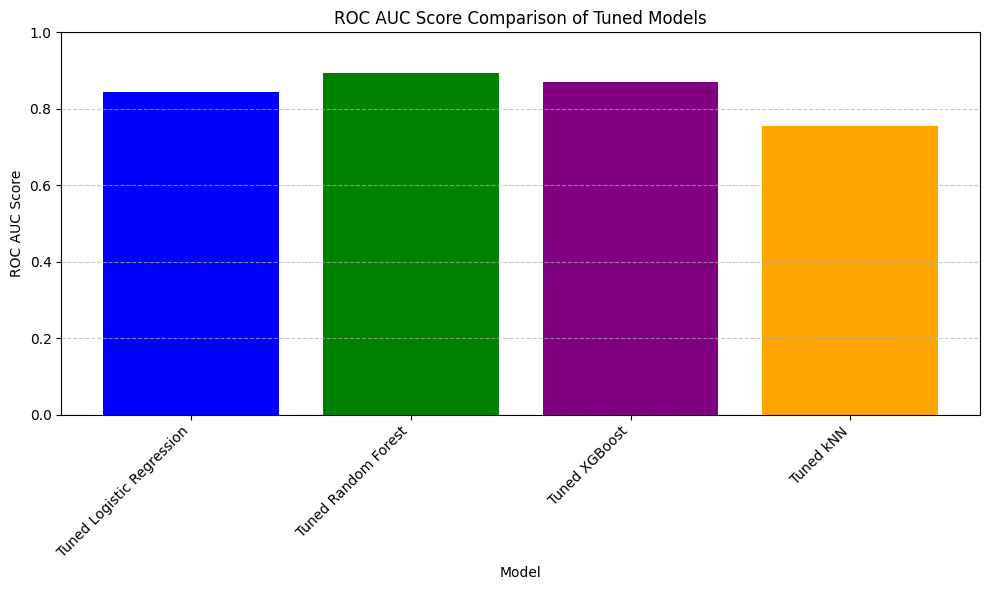

In [23]:
# Extract ROC AUC scores for each model
roc_auc_scores = comparison_df['ROC AUC Score']
model_names = comparison_df.index

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(model_names, roc_auc_scores, color=['blue', 'green', 'purple', 'orange'])

# Add title and labels
plt.title('ROC AUC Score Comparison of Tuned Models')
plt.xlabel('Model')
plt.ylabel('ROC AUC Score')
plt.ylim(0.0, 1.0) # ROC AUC scores are between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()


## ROC Curves
Generate a single plot containing the ROC curves for the tuned Logistic Regression, Random Forest, XGBoost, and kNN models. Each curve should be distinctively colored and labeled with its corresponding ROC AUC score. The plot should include a random classifier baseline, a title, and axis labels for clarity.

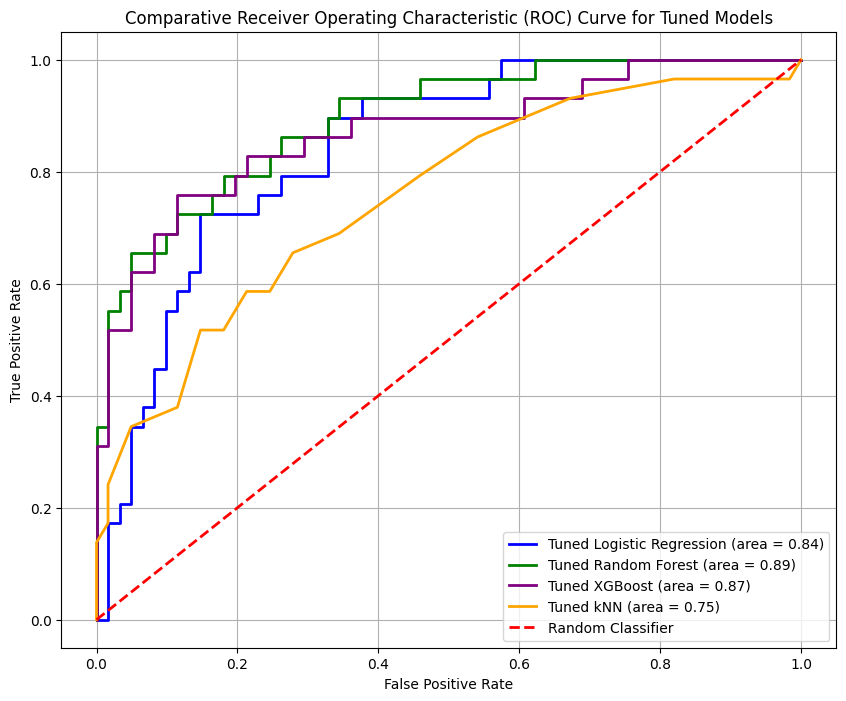

In [24]:
plt.figure(figsize=(10, 8))

# Plot ROC curve for Tuned Logistic Regression
plt.plot(fpr_tuned, tpr_tuned, color='blue', lw=2, label=f'Tuned Logistic Regression (area = {roc_auc_tuned:.2f})')

# Plot ROC curve for Tuned Random Forest
plt.plot(fpr_tuned_rf, tpr_tuned_rf, color='green', lw=2, label=f'Tuned Random Forest (area = {roc_auc_tuned_rf:.2f})')

# Plot ROC curve for Tuned XGBoost
plt.plot(fpr_tuned_xgb, tpr_tuned_xgb, color='purple', lw=2, label=f'Tuned XGBoost (area = {roc_auc_tuned_xgb:.2f})')

# Plot ROC curve for Tuned kNN
plt.plot(fpr_tuned_knn, tpr_tuned_knn, color='orange', lw=2, label=f'Tuned kNN (area = {roc_auc_tuned_knn:.2f})')

# Add random classifier baseline
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')

# Set labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative Receiver Operating Characteristic (ROC) Curve for Tuned Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## Summary

### Q&A
The best-performing model based on the collected metrics is **Tuned XGBoost**, which achieved the highest accuracy of approximately 0.844 and a competitive ROC AUC score of 0.871. Tuned Random Forest is a close second with an accuracy of approximately 0.833 and the highest ROC AUC score of 0.895.

**Relative Strengths and Weaknesses:**
*   **Tuned XGBoost:**
    *   **Strengths:** Highest overall accuracy (0.844) and strong precision/recall for both classes, indicating a balanced performance. Good at identifying both positive and negative classes. High Precision (Class 1) at 0.857 suggests fewer false positives for the minority class.
    *   **Weaknesses:** Slightly lower ROC AUC compared to Random Forest, meaning it might not be as good at distinguishing between classes across all possible thresholds.
*   **Tuned Random Forest:**
    *   **Strengths:** Highest ROC AUC score (0.895), indicating excellent discriminatory power between classes. High Recall (Class 0) at 0.951, meaning it effectively identifies the majority class. Good overall accuracy (0.833).
    *   **Weaknesses:** Slightly lower accuracy than XGBoost.
*   **Tuned Logistic Regression:**
    *   **Strengths:** Better than kNN, particularly in ROC AUC.
    *   **Weaknesses:** Moderate performance across all metrics (e.g., Accuracy ~0.744, ROC AUC ~0.845) compared to tree-based models, and relatively low Recall for Class 1 (0.379), suggesting it misses many positive instances.
*   **Tuned kNN:**
    *   **Strengths:** Highest Recall for Class 0 (0.984), meaning it's very good at identifying the majority class.
    *   **Weaknesses:** Significantly lowest performance in terms of accuracy (0.722) and ROC AUC (0.754). Very low Recall for Class 1 (0.172) indicates it struggles significantly with identifying the minority class, making it unsuitable for problems where identifying positive cases is critical.

### Data Analysis Key Findings
*   **XGBoost** emerged as the most accurate model with an accuracy of approximately 0.844.
*   **Random Forest** achieved the highest ROC AUC score of approximately 0.895, indicating strong discriminatory power.
*   **XGBoost** showed strong precision for Class 1 (0.857), suggesting a low rate of false positives for the positive class.
*   **Random Forest** also performed well with high Recall for Class 0 (0.951).
*   **kNN** exhibited the lowest performance across most metrics, with an accuracy of approximately 0.722 and a significantly low Recall for Class 1 (0.172), indicating poor identification of the minority class.
*   **Logistic Regression** showed moderate performance compared to the tree-based models, with an accuracy of approximately 0.744 and ROC AUC of 0.845.
*   A bar chart visualization confirmed the superior ROC AUC scores of Random Forest and XGBoost compared to Logistic Regression and kNN.

### Insights or Next Steps
*   For this specific problem, **Tuned Random Forest and Tuned XGBoost** are the best-performing models, offering a strong balance of accuracy and class discrimination. The choice between them might depend on the specific business need, e.g., if minimizing false positives (XGBoost's higher Precision C1) or maximizing overall true positive rate across thresholds (Random Forest's higher ROC AUC) is more critical.
*   Further investigation could involve an ensemble approach combining the strengths of Random Forest and XGBoost, or a deeper dive into feature importance from these models to gain business insights. Additionally, evaluating the computational cost and interpretability of these models could inform the final deployment decision.
